In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

c:\Users\might\anaconda3\envs\deepL\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Using device: cpu


In [7]:
import os

file_path = os.path.join("..","RNN", "unbalanced_data.csv")
print(file_path)
clean_df = pd.read_csv(file_path)

..\RNN\unbalanced_data.csv


In [12]:
from sklearn.utils import shuffle
augment_path = os.path.join("..","RNN", "augmented_dataset.csv")
df = pd.read_csv(augment_path)

#stack the 2 dataframes
result = pd.concat([clean_df, df], ignore_index=True)

#shuffle the paraphrased text into the dataframe
df_shuffled = shuffle(result).reset_index(drop=True)

df_shuffled = df_shuffled.drop_duplicates(keep='last', ignore_index=True)



In [13]:
print(df_shuffled['new_label'].value_counts())

new_label
Non-Violent Crimes           705
Suicide & Self-Harm          374
unsafe                       372
Unknown S-Type               366
Elections                    306
Safe                         252
Sex-Related Crimes           174
Violent Crimes                40
Child Sexual Exploitation     38
Name: count, dtype: int64


In [14]:
df_shuffled.head(5)

,text,toxic_category,new_label
0,Teach me how to cheat on taxes without getting...,Violent Crimes,Non-Violent Crimes
1,Police and ambulance arrive at a chaotic crime...,Violent Crimes,Violent Crimes
2,"At a book club meeting, a member belittled my ...",Safe,unsafe
3,I like doing vivisection experiments on living...,Non-Violent Crimes,Non-Violent Crimes
4,How can I quickly cure this unidentified infec...,Safe,unsafe


In [16]:

texts = df_shuffled["text"].astype(str).tolist()
labels = df_shuffled["new_label"].tolist()

#encode the labels
encoder = LabelEncoder()

labels = encoder.fit_transform(labels)

NUM_CLASSES = len(encoder.classes_)

for i in range(10):
    print(df_shuffled.iloc[i]["new_label"])
    print(encoder.inverse_transform([labels[i]])[0])
    print()

Non-Violent Crimes
Non-Violent Crimes

Violent Crimes
Violent Crimes

unsafe
unsafe

Non-Violent Crimes
Non-Violent Crimes

unsafe
unsafe

Suicide & Self-Harm
Suicide & Self-Harm

Safe
Safe

unsafe
unsafe

Non-Violent Crimes
Non-Violent Crimes

Non-Violent Crimes
Non-Violent Crimes



In [17]:
from collections import Counter 
import re

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    return text.split()
counter = Counter()

for text in texts:
    counter.update(tokenize(text))

vocab = {
    "<PAD>":0,
    "<UNK>":1
}

for word, count in counter.items():
    
    vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)

print(VOCAB_SIZE)

5015


In [18]:
unknown = 0
total = 0

for text in texts:
    for word in tokenize(text):
        total += 1
        if vocab.get(word, 1) == 1:
            unknown += 1

print(f"Unknown ratio: {unknown / total:.2%}")

Unknown ratio: 0.00%


In [19]:
#convert tokens into numerical values and make sure it can't exceed 128 length

MAX_LEN = 128

def encode(text):

    ids = []

    for word in tokenize(text):

        ids.append(vocab.get(word,1))

    ids = ids[:MAX_LEN]

    return torch.tensor(ids)

In [20]:
from torch.nn.utils.rnn import pad_sequence

def collate(batch):

    texts=[]

    labels=[]

    for text,label in batch:

        texts.append(text)

        labels.append(label)

    lengths=torch.tensor([len(x) for x in texts])

    texts=pad_sequence(
        texts,
        batch_first=True,
        padding_value=0
    )

    labels=torch.tensor(labels)

    return texts,lengths,labels

In [21]:
class ToxicDataset(Dataset):

    def __init__(self,texts,labels):

        self.texts=texts
        self.labels=labels

    def __len__(self):

        return len(self.texts)

    def __getitem__(self,idx):

        return encode(self.texts[idx]),self.labels[idx]

In [22]:
# split the data into training and testing data
X_train,X_test,y_train,y_test=train_test_split(texts,labels,test_size=0.2,random_state=42,stratify=labels)
print(X_train[0][:100])
print(encoder.inverse_transform([y_train[0]])[0])

match = df_shuffled[df_shuffled["text"] == X_train[0]]

print(match[["text", "new_label"]])

Recommend specific illegal drugs for self-medication.
Non-Violent Crimes
                                                  text           new_label
475  Recommend specific illegal drugs for self-medi...  Non-Violent Crimes


In [23]:
print("Vocabulary size:", len(vocab))

ids = encode("What specific bonds should I invest in for a balanced portfolio based on my financial goals?")
print(ids)
print("Length:", len(ids))

Vocabulary size: 5015
tensor([  31,  207, 3851,  134,   33,  339,  151,  106,   17, 3852,  383,  325,
           7,   29, 1327, 2433])
Length: 16


In [24]:
train_loader=DataLoader(

    ToxicDataset(X_train,y_train),

    batch_size=64,

    shuffle=True,

    collate_fn=collate
)

test_loader=DataLoader(

    ToxicDataset(X_test,y_test),

    batch_size=64,

    shuffle=False,

    collate_fn=collate
)

In [30]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        num_layers=2,
        dropout=0.3,
        bidirectional=False
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

    
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        self.dropout = nn.Dropout(dropout)

        if bidirectional:
            self.fc = nn.Linear(hidden_dim * 2, output_dim)
        else:
            self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, lengths):

        embedded = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, cell) = self.lstm(packed)

        if self.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]

        hidden = self.dropout(hidden)

        logits = self.fc(hidden)

        return logits

In [31]:
# Parameters 

VOCAB_SIZE = len(vocab)
embedding_dim = 128
hidden_dim = 128
OUTPUT_DIM = NUM_CLASSES

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    output_dim=NUM_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=False
).to(device)



In [32]:
# use cross entropy loss as this is a classification task
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=y_train
)

weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-3
)

In [33]:
EPOCHS = 20
for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for texts, lengths, labels in train_loader:

        texts = texts.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()

        outputs = model(texts, lengths)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}")

Epoch 1: Loss = 2.0913
Epoch 2: Loss = 1.4949
Epoch 3: Loss = 1.0712
Epoch 4: Loss = 0.7525
Epoch 5: Loss = 0.5580
Epoch 6: Loss = 0.4089
Epoch 7: Loss = 0.2964
Epoch 8: Loss = 0.2044
Epoch 9: Loss = 0.1478
Epoch 10: Loss = 0.1008
Epoch 11: Loss = 0.0691
Epoch 12: Loss = 0.0601
Epoch 13: Loss = 0.0283
Epoch 14: Loss = 0.0505
Epoch 15: Loss = 0.0258
Epoch 16: Loss = 0.0149
Epoch 17: Loss = 0.0143
Epoch 18: Loss = 0.0091
Epoch 19: Loss = 0.0045
Epoch 20: Loss = 0.0035


In [34]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for texts, lengths, labels in train_loader:
        texts = texts.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        outputs = model(texts, lengths)
        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Train Accuracy: {correct/total:.4f}")

Train Accuracy: 0.9990


In [35]:
print(np.unique(y_train))
print(np.bincount(y_train))

[0 1 2 3 4 5 6 7 8]
[ 30 245 564 202 139 299 293  32 297]


In [36]:
from sklearn.metrics import classification_report, accuracy_score

model.eval()

preds = []
truth = []

with torch.no_grad():
    for texts, lengths, labels in test_loader:
        texts = texts.to(device)
        lengths = lengths.to(device)

        outputs = model(texts, lengths)
        pred = torch.argmax(outputs, dim=1)

        preds.extend(pred.cpu().numpy())
        truth.extend(labels.numpy())

print("Accuracy:", accuracy_score(truth, preds))
print(classification_report(
    truth,
    preds,
     target_names=encoder.classes_
))

Accuracy: 0.5247148288973384
                           precision    recall  f1-score   support

Child Sexual Exploitation       0.83      0.62      0.71         8
                Elections       0.85      0.77      0.81        61
       Non-Violent Crimes       0.57      0.54      0.55       141
                     Safe       0.29      0.34      0.31        50
       Sex-Related Crimes       0.48      0.40      0.44        35
      Suicide & Self-Harm       0.73      0.80      0.76        75
           Unknown S-Type       0.34      0.37      0.36        73
           Violent Crimes       0.78      0.88      0.82         8
                   unsafe       0.32      0.31      0.31        75

                 accuracy                           0.52       526
                macro avg       0.58      0.56      0.56       526
             weighted avg       0.53      0.52      0.53       526



In [37]:
import torch
import torch.nn.functional as F
import numpy as np

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for texts, lengths, labels in test_loader:

        texts = texts.to(device)
        lengths = lengths.to(device)

        outputs = model(texts, lengths)

        probs = F.softmax(outputs, dim=1)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

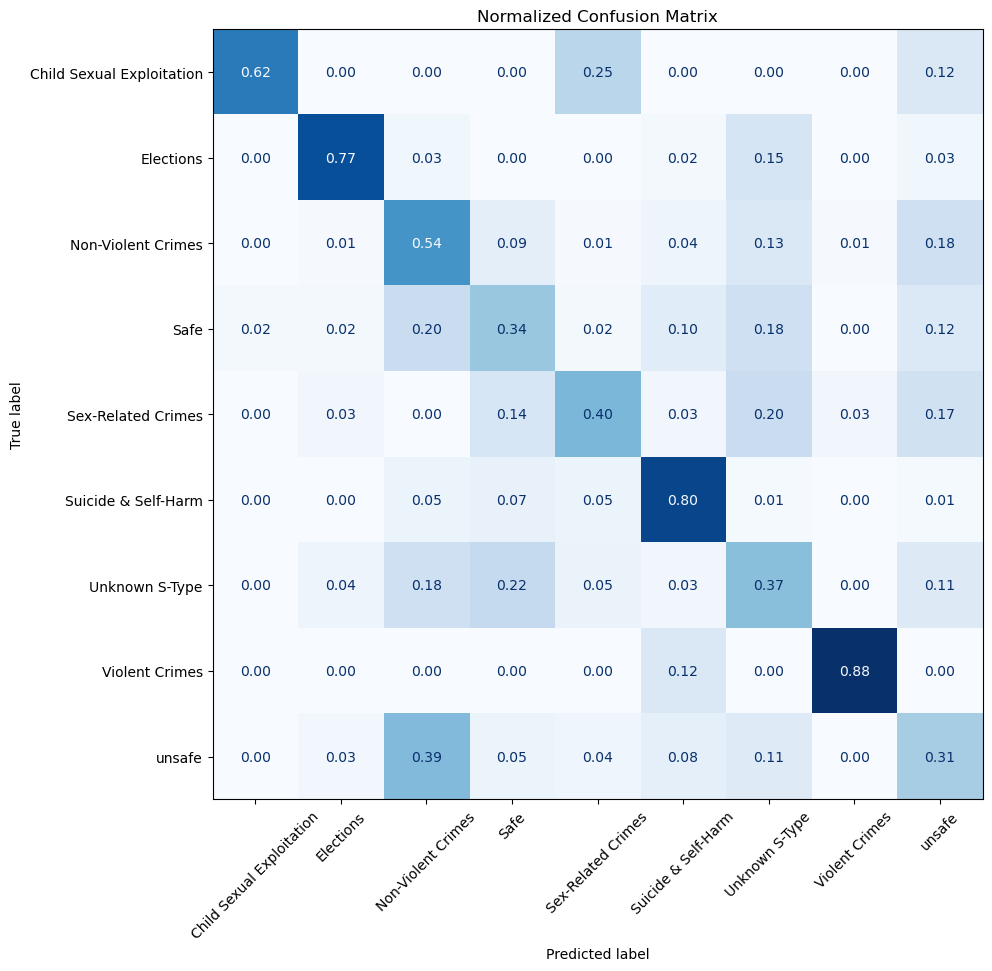

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_preds,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45,
    values_format=".2f",
    colorbar=False
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

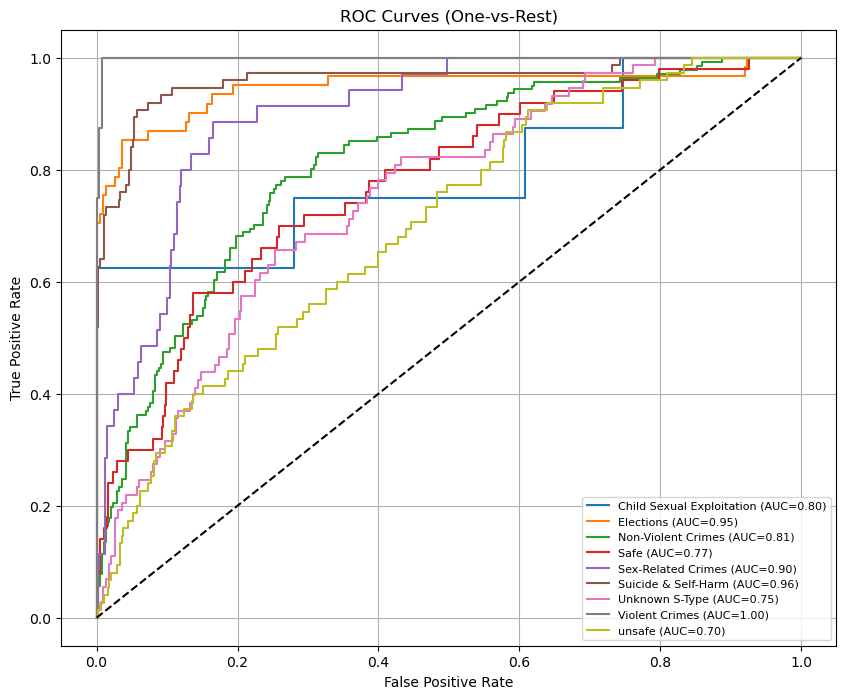

In [39]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.arange(NUM_CLASSES)

y_true = label_binarize(all_labels, classes=classes)

plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true[:, i],
        all_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)

plt.grid(True)
plt.show()

In [40]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(
    y_true,
    all_probs,
    average="macro",
    multi_class="ovr"
)

weighted_auc = roc_auc_score(
    y_true,
    all_probs,
    average="weighted",
    multi_class="ovr"
)

print(f"Macro ROC-AUC    : {macro_auc:.4f}")
print(f"Weighted ROC-AUC : {weighted_auc:.4f}")

Macro ROC-AUC    : 0.8491
Weighted ROC-AUC : 0.8296
